In [1]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
#%load_ext autoreload
#%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD_lab2
import time
import numpy as np
import matplotlib.pyplot as plt

LOG.propagate = False

In [3]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()

2026-02-17 06:13:30,777 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:b4:24:2b:64
2026-02-17 06:13:30,778 | INFO     |: Scanning for device with address: c0:81:b4:24:2b:64, service UUID: 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-02-17 06:13:40,980 | INFO     |: Found 1 device(s) advertising service 15bb5de7-5941-4ba2-bda0-784bb8817a1b
2026-02-17 06:13:40,996 | INFO     |: Selecting device: 38645F53-E5BF-2155-7DF0-DBDE5B0B8B54 (name: Artemis BLE)
2026-02-17 06:13:41,844 | INFO     |: Connected to c0:81:b4:24:2b:64


## Accelerometer

### Graph of accelerometer pitch and roll angles (original) over time ###

In [4]:
timestamps = []
accel_pitches = []
accel_rolls = []
accel_pitches_lpf = []
accel_rolls_lpf = []
def accel_reading_notif_handler(uuid, byte_array):
    # get data from Artemis through ble
    s = ble.bytearray_to_string(byte_array)
    # split string (e.g. ""Accel_pitch:123,Accel_roll:123,Accel_roll_lpf:123,Accel_pitch_lpf:123,T:1234"") into key-value pairs
    s_split = dict(item.split(":") for item in s.split(","))
    # append values to arrays for plotting
    accel_pitches.append(float(s_split["Accel_pitch"]))
    accel_rolls.append(float(s_split["Accel_roll"]))
    accel_pitches_lpf.append(float(s_split["Accel_pitch_lpf"]))
    accel_rolls_lpf.append(float(s_split["Accel_roll_lpf"]))
    timestamps.append(int(s_split["T"]))

In [5]:
# clear old data
timestamps.clear()
accel_pitches.clear()
accel_rolls.clear()
accel_pitches_lpf.clear()
accel_rolls_lpf.clear()

ble.start_notify(ble.uuid['RX_STRING'], accel_reading_notif_handler)

#collect samples for 5 seconds, once every 50ms (20 Hz, so Python slows down send_command, Artemis BLE stack wouldn't gert flooded before Artemis can process commands fast enough)
DURATION = 5
SAMPLE_DELAY = 0.05 # 0.05s

t_start = time.time()
while time.time() - t_start < DURATION: #reach 5 seconds
    ble.send_command(CMD_lab2.GET_ACCEL_DATA, "")
    time.sleep(SAMPLE_DELAY)
print(f"Collected {len(timestamps)} samples in 5 seconds") # also indicate data finishes collecting!
ble.stop_notify(ble.uuid['RX_STRING'])

Collected 45 samples in 5 seconds


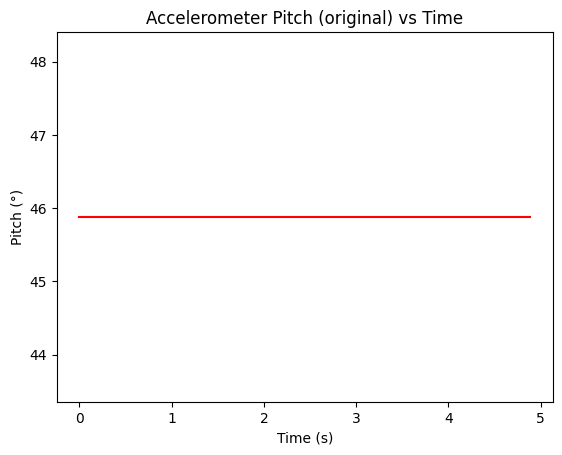

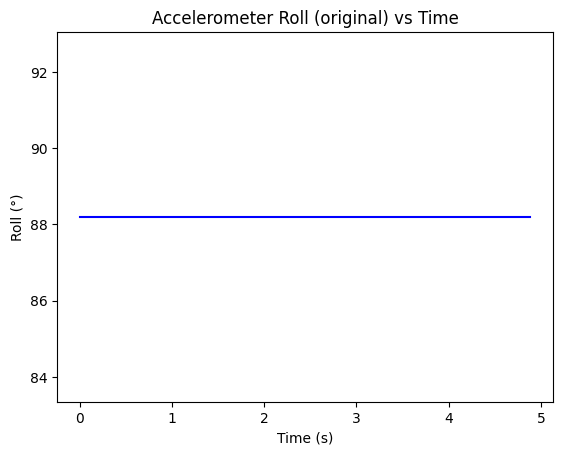

In [6]:
t = np.array(timestamps) # timestamps in ms, since board is booted
t = (t - t[0])/1000 # first sample starts at 0 instead if the actual time since board is boot, convert ms to s
# plot pitch
plt.figure()
plt.plot(t, accel_pitches, color='red')
plt.ylabel("Pitch (°)")
plt.xlabel("Time (s)")
plt.title("Accelerometer Pitch (original) vs Time")
plt.show()
# plot roll
plt.figure()
plt.plot(t, accel_rolls, color='blue')
plt.ylabel("Roll (°)")
plt.xlabel("Time (s)")
plt.title("Accelerometer Roll (original) vs Time")
plt.show()

### Accuracy of Accelerometer (two-point calibration) ###

Collect data, hold IMU at +90° edge

In [7]:
#take the mean of collected data
mean_pitch_90_measured = np.mean(accel_pitches)
mean_roll_90_measured = np.mean(accel_rolls)
print(f"Mean pitch: {mean_pitch_90_measured}")
print(f"Mean roll: {mean_roll_90_measured}")

Mean pitch: 45.88100000000001
Mean roll: 88.19700000000002


Collect data, hold IMU at -90° edge

In [7]:
#take the mean of collected data
mean_pitch_neg_90_measured = np.mean(accel_pitches)
mean_roll_neg_90_measured = np.mean(accel_rolls)
print(f"Mean pitch: {mean_pitch_neg_90_measured}")
print(f"Mean roll: {mean_roll_neg_90_measured}")

Mean pitch: 46.13000000000001
Mean roll: 73.40700000000001


Calculate the conversion factor (scale & offset) such that the final output matches the expected output (so final output is corrected to match true angle). <br>
***calibrated_angle*** = scale * measure_angle + offset <br>
***scale*** = expected/measured <br>
***offset*** = how much more to shift after scaling to get measured angle to match true angle

In [14]:
#pitch
pitch_scale = 180.0/(mean_pitch_90_measured - mean_pitch_neg_90_measured) #reduce error effect
pitch_offset = 90.0 - pitch_scale*mean_pitch_90_measured
#roll
roll_scale = 180.0/(mean_roll_90_measured - mean_roll_neg_90_measured)
roll_offset = 90.0 - roll_scale*mean_roll_90_measured


/var/folders/rf/zx51flzx4bb8c4kh6fv2_1ww0000gn/T/ipykernel_29052/1606722130.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  pitch_scale = 180.0/(mean_pitch_90_measured - mean_pitch_neg_90_measured) #reduce error effect
/var/folders/rf/zx51flzx4bb8c4kh6fv2_1ww0000gn/T/ipykernel_29052/1606722130.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  roll_scale = 180.0/(mean_roll_90_measured - mean_roll_neg_90_measured)


In [14]:
#pitch
pitch_scale = 180.0/(mean_pitch_90_measured - mean_pitch_neg_90_measured) #reduce error effect
pitch_offset = 90.0 - pitch_scale*mean_pitch_90_measured
#roll
roll_scale = 180.0/(mean_roll_90_measured - mean_roll_neg_90_measured)
roll_offset = 90.0 - roll_scale*mean_roll_90_measured


/var/folders/rf/zx51flzx4bb8c4kh6fv2_1ww0000gn/T/ipykernel_29052/1606722130.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  pitch_scale = 180.0/(mean_pitch_90_measured - mean_pitch_neg_90_measured) #reduce error effect
/var/folders/rf/zx51flzx4bb8c4kh6fv2_1ww0000gn/T/ipykernel_29052/1606722130.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  roll_scale = 180.0/(mean_roll_90_measured - mean_roll_neg_90_measured)


### Accelerometer Noise ###

In time domain:

In frequency domain (Fourier Transform in Python):

Good cutoff frequency:

### Graph of accelerometer pitch and roll angles (low pass filtered) over time

## Gyroscope

### Graph of gyroscope pitch, roll, yaw angles over time

At sampling frequency of ___

At sampling frequency of ___

## Complementary Filter

### Graph of complementary filtered pitch and roll angles over time

Working range and accuracy of complementary filtered pitch and roll angles

## Sample Data

In [ ]:
ble.disconnect()